# Deteksi Outlier Konsentrasi 4 Polutan (CH4, CO, NO2, SO2) Menggunakan Metode Iterative Z-Score Bertahap

**Dataset**: `data/csv/Hasil Polutan.csv` (Rentang 1 - 365 Hari Pengamatan: 24 Agustus 2025 s.d. 23 Agustus 2026)  
**Tujuan**: Melakukan identifikasi dan pembersihan data pencilan (*outliers*) pada 4 polutan udara (`CH4`, `CO`, `NO2`, `SO2`) secara bertahap (iteratif) menggunakan aturan ambang batas $3\sigma$ ($|Z| > 3.0$), menyajikan visualisasi runtun waktu komparatif, menyusun **tabel urutan data outlier** secara terstruktur di bawah visualisasi, serta mengekspor dataset bersih terstandarisasi untuk tahapan penambalan nilai kosong (*missing value*).

## Tahap 1: Memuat Data dan Eksplorasi Profil 4 Polutan (Hari 1 - 365)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Pemuatan dataset mentah hasil observasi 4 polutan
input_path = "../data/csv/Hasil Polutan.csv"
if not os.path.exists(input_path):
    input_path = "data/csv/Hasil Polutan.csv"

df_raw = pd.read_csv(input_path)

# 2. Pembatasan tepat pada rentang 365 hari pengamatan pertama
df = df_raw.iloc[:365].copy()
df['tanggal'] = pd.to_datetime(df['tanggal'])

pollutants = ['CH4', 'CO', 'NO2', 'SO2']

# 3. Profil ketersediaan data 4 polutan
profil_data = []
for p in pollutants:
    n_valid = df[p].notna().sum()
    n_missing = df[p].isna().sum()
    pct_valid = (n_valid / len(df)) * 100
    pct_missing = (n_missing / len(df)) * 100
    profil_data.append({
        'Polutan': p,
        'Total Hari': len(df),
        'Data Valid (Hari)': n_valid,
        'Persentase Valid (%)': f"{pct_valid:.2f}%",
        'Missing Values (Hari)': n_missing,
        'Persentase Missing (%)': f"{pct_missing:.2f}%"
    })

df_profil = pd.DataFrame(profil_data)

print("=== PROFIL DATASET 4 POLUTAN 1 TAHUN (HARI 1 - 365) ===")
print(f"Total Baris Data        : {len(df)} hari")
print(f"Rentang Tanggal         : {df['tanggal'].min().strftime('%Y-%m-%d')} s.d. {df['tanggal'].max().strftime('%Y-%m-%d')}")
display(df_profil)

print("\n--- 5 Baris Pertama Dataset ---")
display(df.head())


=== PROFIL DATASET 4 POLUTAN 1 TAHUN (HARI 1 - 365) ===
Total Baris Data        : 365 hari
Rentang Tanggal         : 2025-08-24 s.d. 2026-08-23


,Polutan,Total Hari,Data Valid (Hari),Persentase Valid (%),Missing Values (Hari),Persentase Missing (%)
0,CH4,365,27,7.40%,338,92.60%
1,CO,365,236,64.66%,129,35.34%
2,NO2,365,218,59.73%,147,40.27%
3,SO2,365,249,68.22%,116,31.78%



--- 5 Baris Pertama Dataset ---


,tanggal,CH4,CO,NO2,SO2
0,2025-08-24,1850.206787,0.032369,0.000030,0.000544
1,2025-08-25,1867.289429,0.029644,0.000040,0.000182
2,2025-08-26,NaN,NaN,0.000046,-0.000258
3,2025-08-27,NaN,0.028471,NaN,0.000107
4,2025-08-28,NaN,0.024230,0.000029,-0.000066


## Tahap 2: Eksplorasi Statistik Deskriptif dan Visualisasi Awal (4 Polutan)

=== TABEL PARAMETER STATISTIK DESKRIPTIF 4 POLUTAN ===


,Polutan,Jumlah Valid,Mean (μ),Std Dev (σ),Median (Q2),Q1 (25%),Q3 (75%),IQR,Min,Max,Skewness,Kurtosis
0,CH4,27,1.886025e+03,1.988513e+01,1.886851e+03,1.879476e+03,1.902061e+03,2.258516e+01,1.841516e+03,1.916853e+03,-0.7108,-0.0068
1,CO,236,2.882526e-02,3.180524e-03,2.864418e-02,2.673603e-02,3.056449e-02,3.828462e-03,2.048735e-02,4.421752e-02,+0.7032,+1.9610
2,NO2,218,3.555625e-05,2.403490e-05,3.145000e-05,2.322500e-05,4.235000e-05,1.912500e-05,5.230000e-06,2.463840e-04,+3.9244,+27.9416
3,SO2,249,6.583455e-05,2.032376e-04,5.170000e-05,-5.500000e-05,1.706310e-04,2.256310e-04,-5.177910e-04,8.077910e-04,+0.4368,+1.4624


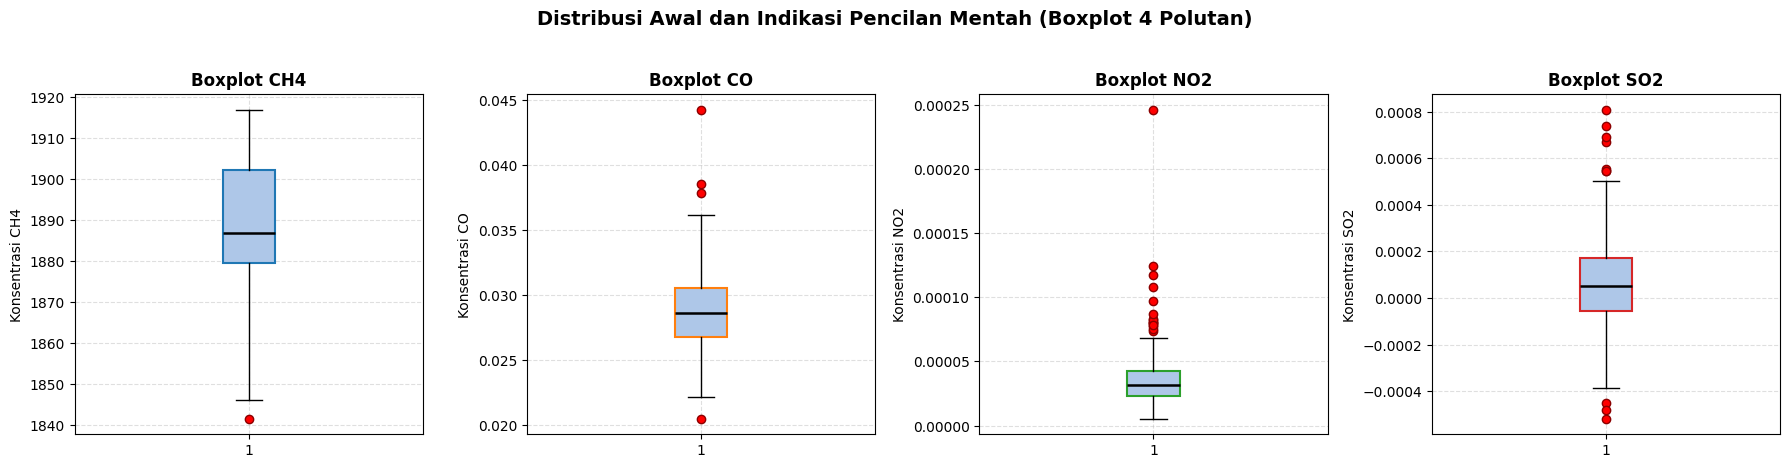

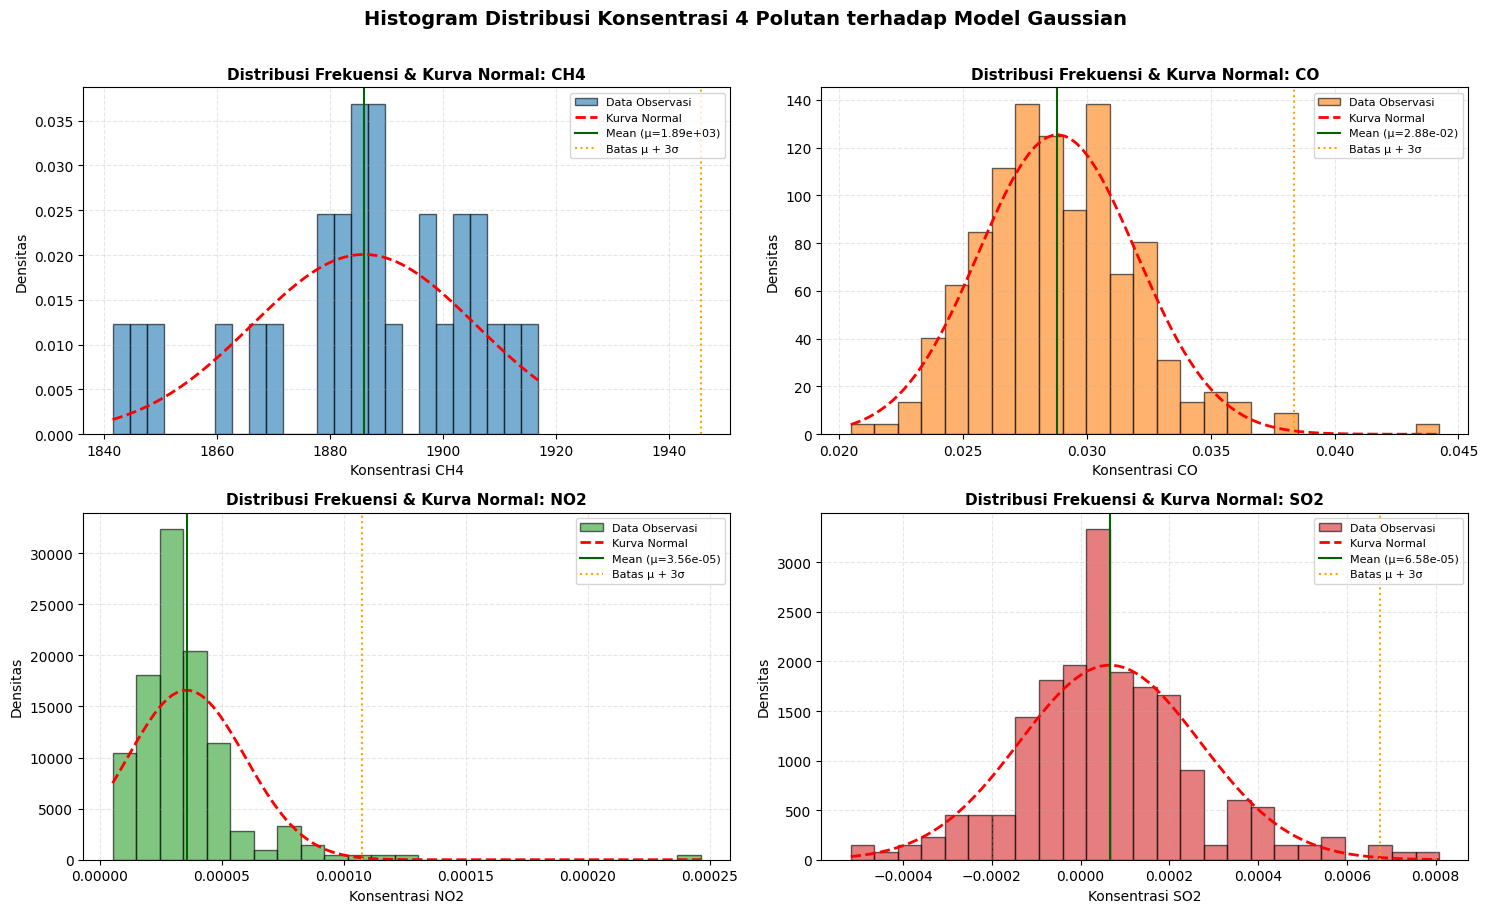

In [2]:
# 1. Komputasi Parameter Statistik Deskriptif 4 Polutan
stats_summary = []
for p in pollutants:
    s = df[p].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    stats_summary.append({
        'Polutan': p,
        'Jumlah Valid': len(s),
        'Mean (μ)': f"{s.mean():.6e}",
        'Std Dev (σ)': f"{s.std():.6e}",
        'Median (Q2)': f"{s.median():.6e}",
        'Q1 (25%)': f"{q1:.6e}",
        'Q3 (75%)': f"{q3:.6e}",
        'IQR': f"{iqr:.6e}",
        'Min': f"{s.min():.6e}",
        'Max': f"{s.max():.6e}",
        'Skewness': f"{s.skew():+.4f}",
        'Kurtosis': f"{s.kurtosis():+.4f}"
    })

df_stat_all = pd.DataFrame(stats_summary)
print("=== TABEL PARAMETER STATISTIK DESKRIPTIF 4 POLUTAN ===")
display(df_stat_all)

# 2. Visualisasi Boxplot Distribusi 4 Polutan
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
box_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, p in enumerate(pollutants):
    s = df[p].dropna()
    axes[i].boxplot(s, patch_artist=True,
                    boxprops=dict(facecolor='#aec7e8', color=box_colors[i], linewidth=1.5),
                    medianprops=dict(color='black', linewidth=1.8),
                    flierprops=dict(marker='o', markerfacecolor='red', markeredgecolor='darkred', markersize=6))
    axes[i].set_title(f'Boxplot {p}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(f'Konsentrasi {p}', fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Distribusi Awal dan Indikasi Pencilan Mentah (Boxplot 4 Polutan)', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# 3. Visualisasi Histogram Frekuensi dan Kurva Normal Teoritis
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for i, p in enumerate(pollutants):
    s = df[p].dropna()
    mean_val = s.mean()
    std_val = s.std()
    
    axes[i].hist(s, bins=25, density=True, alpha=0.6, color=box_colors[i], edgecolor='black', label='Data Observasi')
    x_axis = np.linspace(s.min(), s.max(), 100)
    axes[i].plot(x_axis, stats.norm.pdf(x_axis, mean_val, std_val), 'r--', linewidth=2, label='Kurva Normal')
    axes[i].axvline(mean_val, color='darkgreen', linestyle='-', linewidth=1.5, label=f'Mean (μ={mean_val:.2e})')
    axes[i].axvline(mean_val + 3 * std_val, color='orange', linestyle=':', linewidth=1.5, label='Batas μ + 3σ')
    if (mean_val - 3 * std_val) >= s.min():
        axes[i].axvline(mean_val - 3 * std_val, color='orange', linestyle=':', linewidth=1.5, label='Batas μ - 3σ')
        
    axes[i].set_title(f'Distribusi Frekuensi & Kurva Normal: {p}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(f'Konsentrasi {p}', fontsize=10)
    axes[i].set_ylabel('Densitas', fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.3)
    axes[i].legend(fontsize=8, loc='upper right')

plt.suptitle('Histogram Distribusi Konsentrasi 4 Polutan terhadap Model Gaussian', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Tahap 3: Deteksi Outlier Bertahap (Iterative Z-Score |Z| > 3.0) untuk 4 Polutan

Pada tahapan ini, diterapkan algoritma **Iterative Z-Score** dengan ambang batas $|Z| > 3.0$ (Aturan 3-Sigma). Metode bertahap ini sangat penting untuk mengatasi fenomena **masking effect** (efek penyamaran) pada data deret waktu polutan, di mana pencilan yang sangat ekstrem pada tahap awal dapat memperbesar simpangan baku ($\sigma$) sehingga menyamarkan pencilan sekunder.

In [3]:
THRESHOLD = 3.0
all_outliers_records = []
detection_logs = {}

print("=" * 80)
print("MEMULAI PROSES DETEKSI Z-SCORE BERTAHAP (ITERATIVE) UNTUK 4 POLUTAN")
print("Ambang Batas: |Z| > 3.0 (Aturan 3-Sigma)")
print("=" * 80)

for pol in pollutants:
    print(f"\n>>> POLUTAN: {pol} <<<")
    df_iter = df.copy()
    pol_records = []
    iteration = 1
    
    while True:
        valid_series = df_iter[pol].dropna()
        if len(valid_series) == 0:
            print(f"Data valid {pol} kosong.")
            break
            
        curr_mean = valid_series.mean()
        curr_std = valid_series.std()
        curr_z = (df_iter[pol] - curr_mean) / curr_std
        round_outliers = curr_z[curr_z.abs() > THRESHOLD]
        
        print(f"--- {pol} | Tahap {iteration} ---")
        print(f"  Rata-rata (μ)        : {curr_mean:.8e}")
        print(f"  Standar Deviasi (σ)  : {curr_std:.8e}")
        print(f"  Outlier Ditemukan    : {len(round_outliers)} titik")
        
        if len(round_outliers) == 0:
            print(f"  ✓ STATUS: KONVERGEN! Polutan {pol} 100% BEBAS DARI OUTLIER pada Tahap {iteration}.")
            detection_logs[pol] = {'iterations': iteration, 'total_outliers': len(pol_records)}
            break
            
        for idx in round_outliers.index:
            tgl = df.loc[idx, 'tanggal'].strftime('%Y-%m-%d')
            val = df_iter.loc[idx, pol]
            z_val = curr_z.loc[idx]
            kategori = 'Pencilan Atas (Tinggi)' if z_val > 0 else 'Pencilan Bawah (Rendah)'
            
            record = {
                'Polutan': pol,
                'Tahap': f"Tahap {iteration}",
                'Index': idx,
                'Hari_Ke': idx + 1,
                'Tanggal': tgl,
                'Nilai': val,
                'Mean_Tahap': curr_mean,
                'Std_Tahap': curr_std,
                'Z_Score': z_val,
                'Kategori': kategori
            }
            pol_records.append(record)
            all_outliers_records.append(record)
            print(f"    * [Hari ke-{idx+1} | {tgl}] Nilai = {val:.6e} | Z = {z_val:+.3f} ({kategori})")
            
        # Hapus pencilan dari iterasi berikutnya (diubah menjadi NaN pada salinan iterasi)
        df_iter.loc[round_outliers.index, pol] = np.nan
        iteration += 1

print("\n" + "=" * 80)
print(f"TOTAL SELURUH OUTLIER TERDETEKSI DARI 4 POLUTAN: {len(all_outliers_records)} TITIK")
print("=" * 80)
for p in pollutants:
    print(f"- {p:5}: {detection_logs[p]['total_outliers']} outlier (Konvergen dalam {detection_logs[p]['iterations']} iterasi)")


MEMULAI PROSES DETEKSI Z-SCORE BERTAHAP (ITERATIVE) UNTUK 4 POLUTAN
Ambang Batas: |Z| > 3.0 (Aturan 3-Sigma)

>>> POLUTAN: CH4 <<<
--- CH4 | Tahap 1 ---
  Rata-rata (μ)        : 1.88602458e+03
  Standar Deviasi (σ)  : 1.98851347e+01
  Outlier Ditemukan    : 0 titik
  ✓ STATUS: KONVERGEN! Polutan CH4 100% BEBAS DARI OUTLIER pada Tahap 1.

>>> POLUTAN: CO <<<
--- CO | Tahap 1 ---
  Rata-rata (μ)        : 2.88252587e-02
  Standar Deviasi (σ)  : 3.18052421e-03
  Outlier Ditemukan    : 2 titik
    * [Hari ke-45 | 2025-10-07] Nilai = 4.421752e-02 | Z = +4.840 (Pencilan Atas (Tinggi))
    * [Hari ke-334 | 2026-07-23] Nilai = 3.851003e-02 | Z = +3.045 (Pencilan Atas (Tinggi))
--- CO | Tahap 2 ---
  Rata-rata (μ)        : 2.87180919e-02
  Standar Deviasi (σ)  : 2.96169645e-03
  Outlier Ditemukan    : 1 titik
    * [Hari ke-32 | 2025-09-24] Nilai = 3.780002e-02 | Z = +3.066 (Pencilan Atas (Tinggi))
--- CO | Tahap 3 ---
  Rata-rata (μ)        : 2.86791137e-02
  Standar Deviasi (σ)  : 2.90730210e-

## Tahap 4: Visualisasi Hasil Deteksi Outlier Bertahap & Tabel Urutan Data Outlier

Berikut adalah penyajian visualisasi deret waktu dari ke-4 polutan udara dengan penanda titik-titik anomali (outlier), **serta tabel urutan data outlier secara lengkap dan terstruktur tepat di bawah gambar visualisasi**.

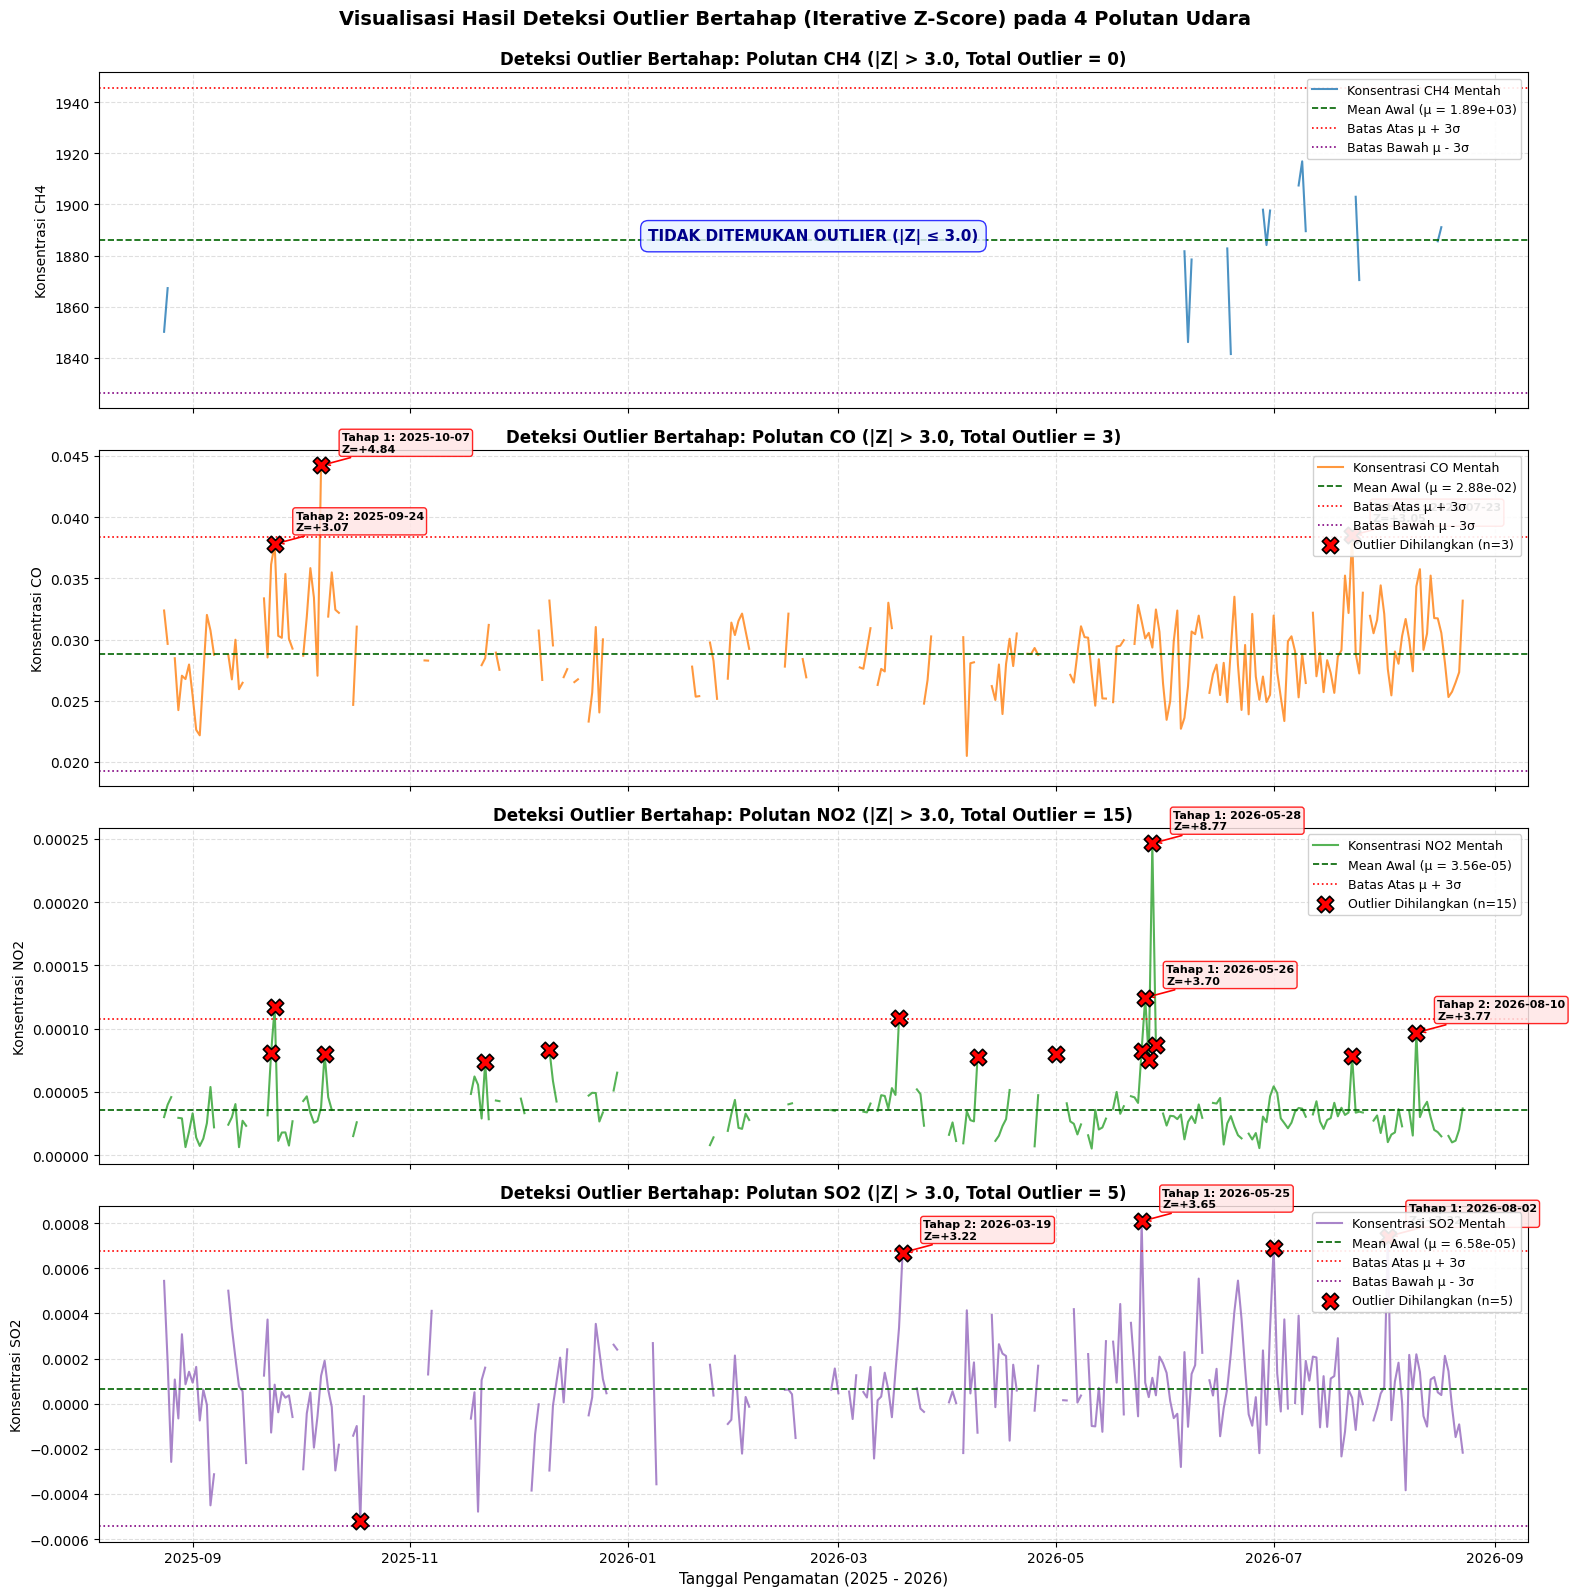

In [4]:
# 1. VISUALISASI HASIL DETEKSI OUTLIER BERTAHAP
fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)
colors_dict = {'CH4': '#1f77b4', 'CO': '#ff7f0e', 'NO2': '#2ca02c', 'SO2': '#9467bd'}

for i, pol in enumerate(pollutants):
    ax = axes[i]
    pol_outliers = [r for r in all_outliers_records if r['Polutan'] == pol]
    outlier_indices = [r['Index'] for r in pol_outliers]
    
    # Nilai dasar awal
    s_init = df[pol].dropna()
    mean_init = s_init.mean()
    std_init = s_init.std()
    
    # 1. Garis deret waktu mentah
    ax.plot(df['tanggal'], df[pol], color=colors_dict[pol], linewidth=1.5, alpha=0.8, label=f'Konsentrasi {pol} Mentah')
    
    # 2. Garis batas statistik
    ax.axhline(mean_init, color='darkgreen', linestyle='--', linewidth=1.2, label=f'Mean Awal (μ = {mean_init:.2e})')
    ax.axhline(mean_init + 3 * std_init, color='red', linestyle=':', linewidth=1.2, label=f'Batas Atas μ + 3σ')
    if (mean_init - 3 * std_init) >= (s_init.min() - 0.1 * abs(s_init.min())):
        ax.axhline(mean_init - 3 * std_init, color='purple', linestyle=':', linewidth=1.2, label=f'Batas Bawah μ - 3σ')
        
    # 3. Scatter plot titik outlier
    if len(outlier_indices) > 0:
        df_out = df.loc[outlier_indices]
        ax.scatter(df_out['tanggal'], df_out[pol], color='red', marker='X', s=140, edgecolor='black', linewidth=1.2, zorder=5,
                   label=f'Outlier Dihilangkan (n={len(outlier_indices)})')
        
        # Anotasi untuk beberapa outlier paling ekstrem
        top_pol_outliers = sorted(pol_outliers, key=lambda x: abs(x['Z_Score']), reverse=True)[:3]
        for item in top_pol_outliers:
            ax.annotate(f"{item['Tahap']}: {item['Tanggal']}\nZ={item['Z_Score']:+.2f}",
                        xy=(pd.to_datetime(item['Tanggal']), item['Nilai']),
                        xytext=(15, 10 if item['Z_Score'] > 0 else -25), textcoords='offset points',
                        fontsize=8, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.25', facecolor='#ffe6e6', edgecolor='red', alpha=0.85),
                        arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
    else:
        ax.text(df['tanggal'].iloc[len(df)//2], mean_init, 'TIDAK DITEMUKAN OUTLIER (|Z| ≤ 3.0)',
                color='darkblue', fontsize=11, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#e6f2ff', edgecolor='blue', alpha=0.8))
        
    ax.set_title(f'Deteksi Outlier Bertahap: Polutan {pol} (|Z| > 3.0, Total Outlier = {len(outlier_indices)})', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Konsentrasi {pol}', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper right', framealpha=0.9, fontsize=9)

axes[-1].set_xlabel('Tanggal Pengamatan (2025 - 2026)', fontsize=11)
plt.suptitle('Visualisasi Hasil Deteksi Outlier Bertahap (Iterative Z-Score) pada 4 Polutan Udara', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


In [5]:
# 2. TABEL URUTAN DATA OUTLIER DI BAWAH VISUALISASI GAMBAR

df_outliers_all = pd.DataFrame(all_outliers_records)

# A. TABEL URUTAN KRONOLOGIS (Berdasarkan Indeks Pengamatan / Hari ke-1 s.d. 365)
df_table_chronological = df_outliers_all.sort_values(by=['Index', 'Polutan']).copy().reset_index(drop=True)
df_table_chronological.index = df_table_chronological.index + 1
df_table_chronological.index.name = 'No'

# Format tampilan numerik yang rapi dan seragam
df_display_chrono = df_table_chronological.copy()
df_display_chrono['Nilai Polutan'] = df_display_chrono['Nilai'].apply(lambda x: f"{x:.6e}")
df_display_chrono['Rata-rata (μ)'] = df_display_chrono['Mean_Tahap'].apply(lambda x: f"{x:.6e}")
df_display_chrono['Std Dev (σ)'] = df_display_chrono['Std_Tahap'].apply(lambda x: f"{x:.6e}")
df_display_chrono['Z-Score'] = df_display_chrono['Z_Score'].apply(lambda x: f"{x:+.4f}")
df_display_chrono['Hari ke-'] = df_display_chrono['Hari_Ke']
df_display_chrono['Tahap Iterasi'] = df_display_chrono['Tahap']

cols_show = ['Polutan', 'Hari ke-', 'Tanggal', 'Nilai Polutan', 'Rata-rata (μ)', 'Std Dev (σ)', 'Z-Score', 'Tahap Iterasi', 'Kategori']

print("=" * 110)
print("TABEL 1: URUTAN KRONOLOGIS SELURUH DATA OUTLIER (BERDASARKAN HARI KE-1 S.D. 365)")
print(f"Total Baris Outlier: {len(df_display_chrono)} Titik Data")
print("=" * 110)
display(df_display_chrono[cols_show])

# B. TABEL URUTAN BERDASARKAN TINGKAT EKSTREMITAS (|Z|-SCORE TERBESAR KE TERKECIL)
df_table_severity = df_outliers_all.copy()
df_table_severity['Abs_Z'] = df_table_severity['Z_Score'].abs()
df_table_severity = df_table_severity.sort_values(by='Abs_Z', ascending=False).reset_index(drop=True)
df_table_severity.index = df_table_severity.index + 1
df_table_severity.index.name = 'Peringkat Ekstrem'

df_display_severity = df_table_severity.copy()
df_display_severity['Nilai Polutan'] = df_display_severity['Nilai'].apply(lambda x: f"{x:.6e}")
df_display_severity['Z-Score'] = df_display_severity['Z_Score'].apply(lambda x: f"{x:+.4f}")
df_display_severity['Hari ke-'] = df_display_severity['Hari_Ke']
df_display_severity['Tahap Iterasi'] = df_display_severity['Tahap']

print("\n" + "=" * 110)
print("TABEL 2: URUTAN OUTLIER BERDASARKAN TINGKAT KEPARAHAN / SIGNIFIKANSI (|Z|-SCORE TERTINGGI)")
print("=" * 110)
display(df_display_severity[['Polutan', 'Hari ke-', 'Tanggal', 'Nilai Polutan', 'Z-Score', 'Tahap Iterasi', 'Kategori']])

# C. TABEL RINGKASAN REKAPITULASI OUTLIER PER POLUTAN
rekap_data = []
for p in pollutants:
    sub = df_outliers_all[df_outliers_all['Polutan'] == p]
    n_valid = df[p].notna().sum()
    n_out = len(sub)
    pct_out = (n_out / n_valid * 100) if n_valid > 0 else 0
    max_z = sub['Z_Score'].abs().max() if n_out > 0 else 0
    tgl_rentang = f"{sub['Tanggal'].min()} s.d. {sub['Tanggal'].max()}" if n_out > 0 else "-"
    
    rekap_data.append({
        'Polutan': p,
        'Data Valid Awal': n_valid,
        'Outlier Ditemukan': n_out,
        'Persentase Outlier': f"{pct_out:.2f}%",
        'Data Bersih Tersisa': n_valid - n_out,
        'Iterasi Hingga Konvergen': detection_logs[p]['iterations'],
        '|Z| Maksimum': f"{max_z:.3f}" if n_out > 0 else "-",
        'Rentang Tanggal Outlier': tgl_rentang
    })

df_rekap = pd.DataFrame(rekap_data)
print("\n" + "=" * 110)
print("TABEL 3: REKAPITULASI HASIL DETEKSI OUTLIER PER POLUTAN")
print("=" * 110)
display(df_rekap)


TABEL 1: URUTAN KRONOLOGIS SELURUH DATA OUTLIER (BERDASARKAN HARI KE-1 S.D. 365)
Total Baris Outlier: 23 Titik Data


,Polutan,Hari ke-,Tanggal,Nilai Polutan,Rata-rata (μ),Std Dev (σ),Z-Score,Tahap Iterasi,Kategori
No,,,,,,,,,
1,NO2,31,2025-09-23,8.080000e-05,3.288292e-05,1.587113e-05,+3.0191,Tahap 3,Pencilan Atas (Tinggi)
2,CO,32,2025-09-24,3.780002e-02,2.871809e-02,2.961696e-03,+3.0665,Tahap 2,Pencilan Atas (Tinggi)
3,NO2,32,2025-09-24,1.170790e-04,3.555625e-05,2.403490e-05,+3.3918,Tahap 1,Pencilan Atas (Tinggi)
4,CO,45,2025-10-07,4.421752e-02,2.882526e-02,3.180524e-03,+4.8395,Tahap 1,Pencilan Atas (Tinggi)
5,NO2,46,2025-10-08,8.010000e-05,3.217407e-05,1.482667e-05,+3.2324,Tahap 4,Pencilan Atas (Tinggi)
6,SO2,56,2025-10-18,-5.177910e-04,5.753804e-05,1.898593e-04,-3.0303,Tahap 2,Pencilan Bawah (Rendah)
7,NO2,91,2025-11-22,7.370000e-05,3.126137e-05,1.343041e-05,+3.1599,Tahap 5,Pencilan Atas (Tinggi)
8,NO2,109,2025-12-10,8.330000e-05,3.288292e-05,1.587113e-05,+3.1767,Tahap 3,Pencilan Atas (Tinggi)
9,NO2,207,2026-03-18,1.082670e-04,3.555625e-05,2.403490e-05,+3.0252,Tahap 1,Pencilan Atas (Tinggi)



TABEL 2: URUTAN OUTLIER BERDASARKAN TINGKAT KEPARAHAN / SIGNIFIKANSI (|Z|-SCORE TERTINGGI)


,Polutan,Hari ke-,Tanggal,Nilai Polutan,Z-Score,Tahap Iterasi,Kategori
Peringkat Ekstrem,,,,,,,
1,NO2,278,2026-05-28,2.463840e-04,+8.7717,Tahap 1,Pencilan Atas (Tinggi)
2,CO,45,2025-10-07,4.421752e-02,+4.8395,Tahap 1,Pencilan Atas (Tinggi)
3,NO2,352,2026-08-10,9.680000e-05,+3.7720,Tahap 2,Pencilan Atas (Tinggi)
4,NO2,276,2026-05-26,1.244530e-04,+3.6987,Tahap 1,Pencilan Atas (Tinggi)
5,SO2,275,2026-05-25,8.077910e-04,+3.6507,Tahap 1,Pencilan Atas (Tinggi)
6,NO2,32,2025-09-24,1.170790e-04,+3.3918,Tahap 1,Pencilan Atas (Tinggi)
7,SO2,344,2026-08-02,7.403350e-04,+3.3188,Tahap 1,Pencilan Atas (Tinggi)
8,NO2,277,2026-05-27,7.560000e-05,+3.3014,Tahap 5,Pencilan Atas (Tinggi)
9,NO2,46,2025-10-08,8.010000e-05,+3.2324,Tahap 4,Pencilan Atas (Tinggi)



TABEL 3: REKAPITULASI HASIL DETEKSI OUTLIER PER POLUTAN


,Polutan,Data Valid Awal,Outlier Ditemukan,Persentase Outlier,Data Bersih Tersisa,Iterasi Hingga Konvergen,|Z| Maksimum,Rentang Tanggal Outlier
0,CH4,27,0,0.00%,27,1,-,-
1,CO,236,3,1.27%,233,3,4.840,2025-09-24 s.d. 2026-07-23
2,NO2,218,15,6.88%,203,6,8.772,2025-09-23 s.d. 2026-08-10
3,SO2,249,5,2.01%,244,3,3.651,2025-10-18 s.d. 2026-08-02


## Tahap 5: Penghilangan Outlier dan Ekspor Data Bersih 4 Polutan

Pada tahap akhir ini:
1. Seluruh titik data yang terdeteksi sebagai outlier pada ke-4 polutan digantikan dengan `NaN` pada struktur runtun waktu 365 hari lengkap (disimpan sebagai `polutan_4_clean.csv`). Berkas ini yang nantinya menjadi input bagi notebook `tambal-missing-4-polutan.ipynb`.
2. Daftar seluruh 23 data outlier diekspor secara terpisah ke `polutan_4_outliers_list.csv` sebagai dokumentasi audit data.
3. Versi alternatif tanpa baris outlier (baris pencilan dibuang) disimpan sebagai `polutan_4_no_outliers.csv`.
4. Dilakukan uji verifikasi Z-score ulang untuk memastikan data bersih **100% bebas dari pencilan**.

In [6]:
# 1. Dataset Bersih Utama: Outlier diubah menjadi NaN (mempertahankan struktur 365 hari lengkap)
df_clean = df.copy()

for r in all_outliers_records:
    pol = r['Polutan']
    idx = r['Index']
    df_clean.loc[idx, pol] = np.nan

# 2. Output folder di data/csv/pertemuan-4-csv
output_folder = "../data/csv/pertemuan-4-csv"
if not os.path.exists(output_folder):
    output_folder = "data/csv/pertemuan-4-csv"
os.makedirs(output_folder, exist_ok=True)

# Ekspor Dataset Bersih Utama
clean_csv_path = os.path.join(output_folder, "polutan_4_clean.csv")
df_clean.to_csv(clean_csv_path, index=False)
print(f"✓ 1. File data bersih 4 polutan (outlier -> NaN) berhasil disimpan di:\n     {clean_csv_path}")

# Ekspor Katalog Outlier
outlier_csv_path = os.path.join(output_folder, "polutan_4_outliers_list.csv")
df_display_chrono[cols_show].to_csv(outlier_csv_path, index=True, index_label='No')
print(f"✓ 2. File katalog data outlier (23 baris) berhasil disimpan di:\n     {outlier_csv_path}")

# Ekspor Alternatif: Dihapus baris outliernya
all_outlier_idx = list(set([r['Index'] for r in all_outliers_records]))
df_dropped = df.drop(index=all_outlier_idx).copy()
dropped_csv_path = os.path.join(output_folder, "polutan_4_no_outliers.csv")
df_dropped.to_csv(dropped_csv_path, index=False)
print(f"✓ 3. File data alternatif (baris outlier dihapus) berhasil disimpan di:\n     {dropped_csv_path}")

# 3. Uji Verifikasi Z-Score Ulang pada Dataset Bersih
print("\n" + "=" * 80)
print("UJI VERIFIKASI Z-SCORE ULANG PADA DATASET BERSIH (AMBANG BATAS |Z| > 3.0)")
print("=" * 80)

verif_rows = []
for p in pollutants:
    s_clean = df_clean[p].dropna()
    z_clean = (s_clean - s_clean.mean()) / s_clean.std()
    sisa_outlier = (z_clean.abs() > THRESHOLD).sum()
    
    verif_rows.append({
        'Polutan': p,
        'Total Baris': len(df_clean),
        'Data Valid Bersih': len(s_clean),
        'Missing Values (NaN)': df_clean[p].isna().sum(),
        'Outlier Sisa (|Z| > 3.0)': sisa_outlier,
        'Status Kebersihan': '100% BEBAS OUTLIER ✓' if sisa_outlier == 0 else 'ADA SISA OUTLIER ✗'
    })

df_verif = pd.DataFrame(verif_rows)
display(df_verif)


✓ 1. File data bersih 4 polutan (outlier -> NaN) berhasil disimpan di:
     ../data/csv/pertemuan-4-csv\polutan_4_clean.csv
✓ 2. File katalog data outlier (23 baris) berhasil disimpan di:
     ../data/csv/pertemuan-4-csv\polutan_4_outliers_list.csv
✓ 3. File data alternatif (baris outlier dihapus) berhasil disimpan di:
     ../data/csv/pertemuan-4-csv\polutan_4_no_outliers.csv

UJI VERIFIKASI Z-SCORE ULANG PADA DATASET BERSIH (AMBANG BATAS |Z| > 3.0)


,Polutan,Total Baris,Data Valid Bersih,Missing Values (NaN),Outlier Sisa (|Z| > 3.0),Status Kebersihan
0,CH4,365,27,338,0,100% BEBAS OUTLIER ✓
1,CO,365,233,132,0,100% BEBAS OUTLIER ✓
2,NO2,365,203,162,0,100% BEBAS OUTLIER ✓
3,SO2,365,244,121,0,100% BEBAS OUTLIER ✓
